## MavenFlix Subscription Cohort Data Analysis using Python 

In [100]:
pip install seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [101]:
#importing the libraries 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [102]:
# reading the CSV data (data is available in https://mavenanalytics.io/data-playground/streaming-video-subscriptions)
MavenFlix_df = pd.read_csv('Subscription Cohort Analysis Data.csv') 

In [103]:
MavenFlix_df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   customer_id            3069 non-null   int64 
 1   created_date           3069 non-null   object
 2   canceled_date          2004 non-null   object
 3   subscription_cost      3069 non-null   int64 
 4   subscription_interval  3069 non-null   object
 5   was_subscription_paid  3069 non-null   object
dtypes: int64(2), object(4)
memory usage: 144.0+ KB


In [104]:
#To convert the dates from object data type to date type
MavenFlix_df['created_date'] = pd.to_datetime(MavenFlix_df['created_date'])
MavenFlix_df['canceled_date'] = pd.to_datetime(MavenFlix_df['canceled_date'])

In [105]:
MavenFlix_df.dtypes

customer_id                       int64
created_date             datetime64[ns]
canceled_date            datetime64[ns]
subscription_cost                 int64
subscription_interval            object
was_subscription_paid            object
dtype: object

### Q1. How have Mavenflix subscriptions trended over time? 

To understand how subscriptions have trended over time, I am taking 'created_date' into consideration. Knowing how many customers have subscribed every month from September 2022 - September 2023, gives an insight to the variation of number of subscriptions.

the below code answers:
1. How many new subscribers monthly?
2. To identify growth and drop periods

In [106]:
# Creating a new column called 'signup_month' which shows the year-month format 
MavenFlix_df['signup_month'] = MavenFlix_df['created_date'].dt.to_period('M')

In [107]:
#Grouping the data by the column 'signup_month' and counting the 'customer_id' signing up for every month
subscription_trend = MavenFlix_df.groupby('signup_month')['customer_id'].count()
subscription_trend

signup_month
2022-09    217
2022-10    196
2022-11    189
2022-12    230
2023-01    273
2023-02    275
2023-03    266
2023-04    223
2023-05    285
2023-06    275
2023-07    306
2023-08    268
2023-09     66
Freq: M, Name: customer_id, dtype: int64

MavenFlix subscriptions show a steady upward trend from late 2022 through mid-2023. Monthly subscriptions increased from 189 in November 2022 to a peak of 306 in July 2023, indicating growing platform adoption. The sharp drop in September 2023 (66 subscriptions) likely reflects incomplete data for the month rather than a true decline.

In [108]:
#o get the realtime date values
subscription_trend.index = subscription_trend.index.to_timestamp()

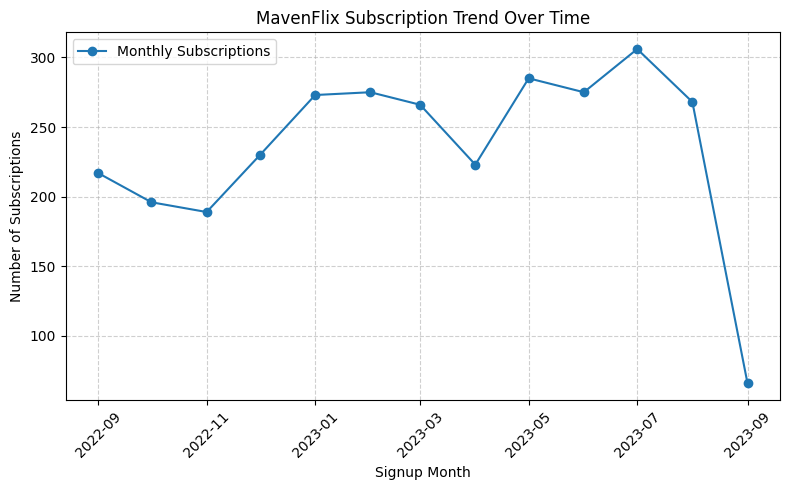

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(subscription_trend.index,
         subscription_trend.values,
         marker='o',
         linestyle='-',
         label="Monthly Subscriptions")

plt.xlabel("Signup Month")
plt.ylabel("Number of Subscriptions")
plt.title("MavenFlix Subscription Trend Over Time")

plt.grid(True,linestyle='--', alpha=0.6)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Q2. What percentage of customers have subscribed for 5 months or more? 

to understand the long-term retention, customers still subscribed to MavenFlix longer than 5 months.

In [110]:
#Define analysis end date,assuming they stayed until the end of the dataset.
analysis_date = pd.Timestamp('2023-09-30')

In [111]:
#To create an end date
MavenFlix_df['end_date'] = MavenFlix_df['canceled_date'].fillna(analysis_date)

In [112]:
#Calculating subscription duration
MavenFlix_df['subscription_length_days'] = (
    MavenFlix_df['end_date'] - MavenFlix_df['created_date']
).dt.days

In [113]:
#Converting to months
MavenFlix_df['subscription_length_months'] = (
    MavenFlix_df['subscription_length_days'] // 30
)

In [114]:
#Customers with ≥ 5 months
customers_5_months = MavenFlix_df[
    MavenFlix_df['subscription_length_months'] >= 5
]

In [115]:
# To get the percentage of customers retained long term 
percentage_5_months = (
    len(customers_5_months) / len(MavenFlix_df)
) * 100

round(percentage_5_months,2)

17.63

Only 17.63% of MavenFlix subscribers remain active for five months or longer. This indicates that the majority of users churn relatively early in their subscription lifecycle, suggesting an opportunity to improve long-term engagement and retention strategies.


## Q3. What month has the highest subscriber retention, the lowest retention?

Retention means how many subscribers from the month they signed up to the later months they are under the subscription. 
this requires cohort analysis

what is cohort analysis?

Cohort analysis is a type of behavior analytics that is used to identify trends in user retention, churn or any actions that are driven by the behavior of the users or customers groups or cohorts 

In [116]:
#to calculate the size of the group or cohort each month
cohort_size = MavenFlix_df.groupby('signup_month')['customer_id'].count()
cohort_size

signup_month
2022-09    217
2022-10    196
2022-11    189
2022-12    230
2023-01    273
2023-02    275
2023-03    266
2023-04    223
2023-05    285
2023-06    275
2023-07    306
2023-08    268
2023-09     66
Freq: M, Name: customer_id, dtype: int64

In [117]:
#to calculate the retention of the cohort over the span of 1 year
retention = {}

max_age = MavenFlix_df['subscription_length_months'].max()

for month in range(int(max_age) + 1):
    retention[month] = (
        MavenFlix_df[MavenFlix_df['subscription_length_months'] >= month]
        .groupby('signup_month')['customer_id']
        .count()
    )

cohort_table = pd.DataFrame(retention)
cohort_table

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
signup_month,,,,,,,,,,,,,,
2022-09,217,162.0,108.0,86.0,68.0,62.0,50.0,41.0,33.0,27.0,25.0,23.0,20.0,5.0
2022-10,196,153.0,108.0,87.0,71.0,56.0,48.0,43.0,38.0,32.0,28.0,28.0,4.0,NaN
2022-11,189,144.0,107.0,78.0,54.0,40.0,34.0,32.0,32.0,27.0,22.0,3.0,NaN,NaN
2022-12,230,181.0,132.0,96.0,78.0,66.0,59.0,50.0,45.0,43.0,10.0,NaN,NaN,NaN
2023-01,273,215.0,153.0,121.0,96.0,83.0,70.0,61.0,56.0,4.0,NaN,NaN,NaN,NaN
2023-02,275,201.0,143.0,118.0,89.0,74.0,66.0,59.0,8.0,NaN,NaN,NaN,NaN,NaN
2023-03,266,201.0,148.0,104.0,85.0,73.0,68.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-04,223,165.0,122.0,95.0,86.0,78.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05,285,222.0,158.0,129.0,106.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
#MavenFlix_df.head(10)

In [127]:
#calculating the retention rate
retention_rate = cohort_table.divide(cohort_size, axis=0)

retention_percentage = round(retention_rate * 100, 2)


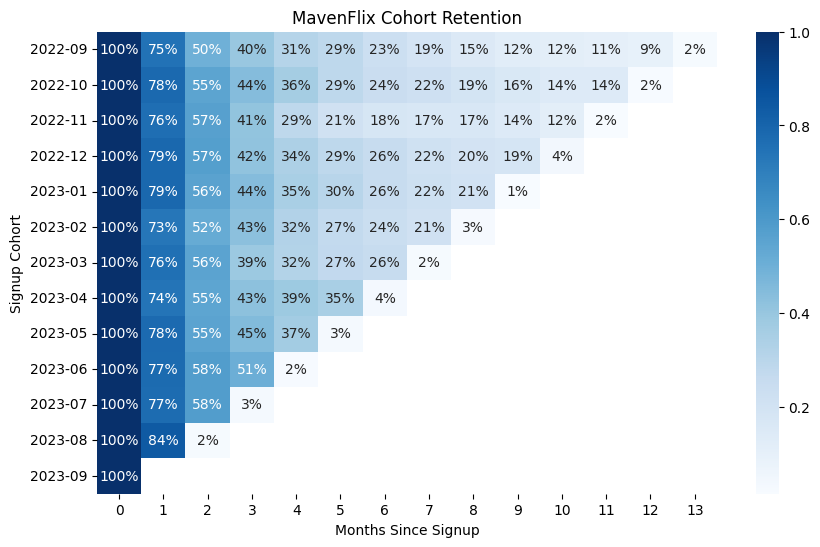

In [126]:
#plotting the heatmap to visually understand the cohort retention 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("MavenFlix Cohort Retention")
plt.ylabel("Signup Cohort")
plt.xlabel("Months Since Signup")

plt.show()

In [120]:
#calculating the cohort retention rate 
cohort_retention = retention_percentage.mean(axis=1)
cohort_retention

signup_month
2022-09     30.512857
2022-10     35.008462
2022-11     33.597500
2022-12     39.131818
2023-01     41.463000
2023-02     41.736667
2023-03     44.688750
2023-04     49.777143
2023-05     53.156667
2023-06     57.672000
2023-07     59.640000
2023-08     62.066667
2023-09    100.000000
Freq: M, dtype: float64

Cohort retention:
Highest retention cohort: August 2023
Lowest retention cohort: September 2022
However, the August cohort appears stronger partly because it is more recent and has had less time for churn to occur. septemeber 2023 is misleading, since there is no enough data to indicate that month's cohort retention. hence ignoring it.

## Additional Insights

## 1. Where does the biggest churn happen?

In [140]:
#shows the first 6 months of retention.
retention_percentage.iloc[:, :6]

,0,1,2,3,4,5
signup_month,,,,,,
2022-09,100.0,74.65,49.77,39.63,31.34,28.57
2022-10,100.0,78.06,55.10,44.39,36.22,28.57
2022-11,100.0,76.19,56.61,41.27,28.57,21.16
2022-12,100.0,78.70,57.39,41.74,33.91,28.70
2023-01,100.0,78.75,56.04,44.32,35.16,30.40
2023-02,100.0,73.09,52.00,42.91,32.36,26.91
2023-03,100.0,75.56,55.64,39.10,31.95,27.44
2023-04,100.0,73.99,54.71,42.60,38.57,34.98
2023-05,100.0,77.89,55.44,45.26,37.19,3.16


Most churn happens in the first 1–2 months.

possible reasons could be:
1. weak content recommendation
2. users not finding value quickly

## 2. Are paid subscribers more loyal?

In [122]:
# adding a new bool column to calculate the mean
MavenFlix_df['was_subscription_paid_bool'] = MavenFlix_df['was_subscription_paid'].map({'Yes': True, 'No': False})

In [123]:
MavenFlix_df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 3069 non-null   int64         
 1   created_date                3069 non-null   datetime64[ns]
 2   canceled_date               2004 non-null   datetime64[ns]
 3   subscription_cost           3069 non-null   int64         
 4   subscription_interval       3069 non-null   object        
 5   was_subscription_paid       3069 non-null   object        
 6   signup_month                3069 non-null   period[M]     
 7   end_date                    3069 non-null   datetime64[ns]
 8   subscription_length_days    3069 non-null   int64         
 9   subscription_length_months  3069 non-null   int64         
 10  was_subscription_paid_bool  3069 non-null   bool          
dtypes: bool(1), datetime64[ns](3), int64(4), object(2), peri

In [124]:
#calculating retention length
MavenFlix_df.groupby('was_subscription_paid_bool')['subscription_length_months'].mean().round(2)


was_subscription_paid_bool
False    0.60
True     2.49
Name: subscription_length_months, dtype: float64

Subscription behavior differs significantly between paid and unpaid users. Non-paying users remain subscribed for an average of only 0.6 months (~18 days), while paying subscribers stay for approximately 2.5 months on average. This indicates that many users churn during or shortly after the free trial period, while paying users demonstrate much stronger retention.

In [125]:
MavenFlix_df['was_subscription_paid_bool'].value_counts()

was_subscription_paid_bool
True     2936
False     133
Name: count, dtype: int64